## 7.2 배치 상호작용(CI)을 이용한 전자구조 계산

In [19]:
# Qiskit 라이브러리 임포트
from qiskit import transpile
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp, Statevector, partial_trace
from qiskit.visualization import plot_bloch_multivector, plot_histogram, plot_state_city
from qiskit_algorithms import VQE
from scipy.optimize import minimize
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import koreanize_matplotlib

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [20]:
# 수소 분자(H₂)의 해밀토니안을 파울리 연산자로 정의
pauli_list = [
    ('II', -1.052373245772859),
    ('ZI',  0.39793742484318045),
    ('IZ', -0.39793742484318045),
    ('ZZ', -0.01128010425623538),
    ('XX',  0.18093119978423156)
]

In [21]:
# 파울리 리스트를 SparsePauliOp 객체로 변환
hamiltonian = SparsePauliOp.from_list(pauli_list)

In [22]:
# AerSimulator로 양자 시뮬레이터 설정
simulator = AerSimulator()

In [23]:
# EfficientSU2 회로로 변분 앤사츠 정의 (전체 얽힘, reps=3)
ansatz = EfficientSU2(num_qubits=2, entanglement='full', reps=3)

In [24]:
# 선택한 앤사츠와 시뮬레이터로 VQE 알고리즘 정의
estimator = StatevectorEstimator()  # 호환성 수정: V2 추정기
vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=minimize)

In [25]:
# VQE 실행으로 바닥상태 에너지 탐색
result = vqe.compute_minimum_eigenvalue(operator=hamiltonian)

In [26]:
# 결과 출력
print("바닥상태 에너지: ", result.eigenvalue.real)
print("최적 매개변수: ", result.optimal_parameters)

바닥상태 에너지:  -1.8572750301969587
최적 매개변수:  {ParameterVectorElement(θ[0]): np.float64(-1.5914174977344437), ParameterVectorElement(θ[1]): np.float64(-0.024313717028850247), ParameterVectorElement(θ[2]): np.float64(2.8426682900060554), ParameterVectorElement(θ[3]): np.float64(1.6912307384476666), ParameterVectorElement(θ[4]): np.float64(2.333194789263379), ParameterVectorElement(θ[5]): np.float64(1.281708139780437), ParameterVectorElement(θ[6]): np.float64(-2.7447254899488733), ParameterVectorElement(θ[7]): np.float64(-1.2980883600247681), ParameterVectorElement(θ[8]): np.float64(-1.7315875591145593), ParameterVectorElement(θ[9]): np.float64(-2.276194819343519), ParameterVectorElement(θ[10]): np.float64(-1.4502703426864265), ParameterVectorElement(θ[11]): np.float64(1.1992139309865049), ParameterVectorElement(θ[12]): np.float64(2.302752771196038), ParameterVectorElement(θ[13]): np.float64(-1.7901540281031503), ParameterVectorElement(θ[14]): np.float64(1.883473015520269), ParameterVectorEle

In [27]:
# VQE가 찾은 매개변수로 최적 회로 생성
optimal_circuit = ansatz.assign_parameters(result.optimal_parameters)

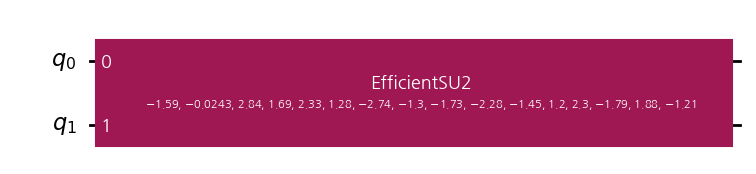

In [28]:
# 최적 회로를 MPL로 그리기
optimal_circuit.draw('mpl')
plt.show()  # 호환성 수정: .show() → plt.show()

In [29]:
# Aer 시뮬레이터와 호환되도록 회로 트랜스파일
transpiled_circuit = transpile(optimal_circuit, simulator)

In [30]:
# 트랜스파일된 회로에 상태벡터 저장 지시
transpiled_circuit.save_statevector()

In [31]:
# Aer 시뮬레이터에서 회로 실행
result = simulator.run(transpiled_circuit).result()
state = result.get_statevector()

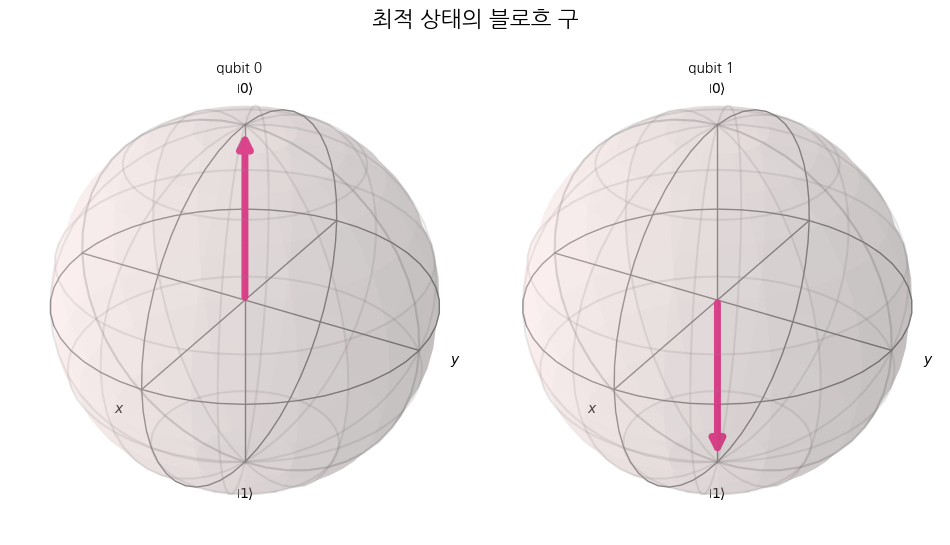

In [32]:
# 첫 큐비트의 블로흐 벡터 그리기
plot_bloch_multivector(state, title="최적 상태의 블로흐 구")
plt.show()  # 호환성 수정

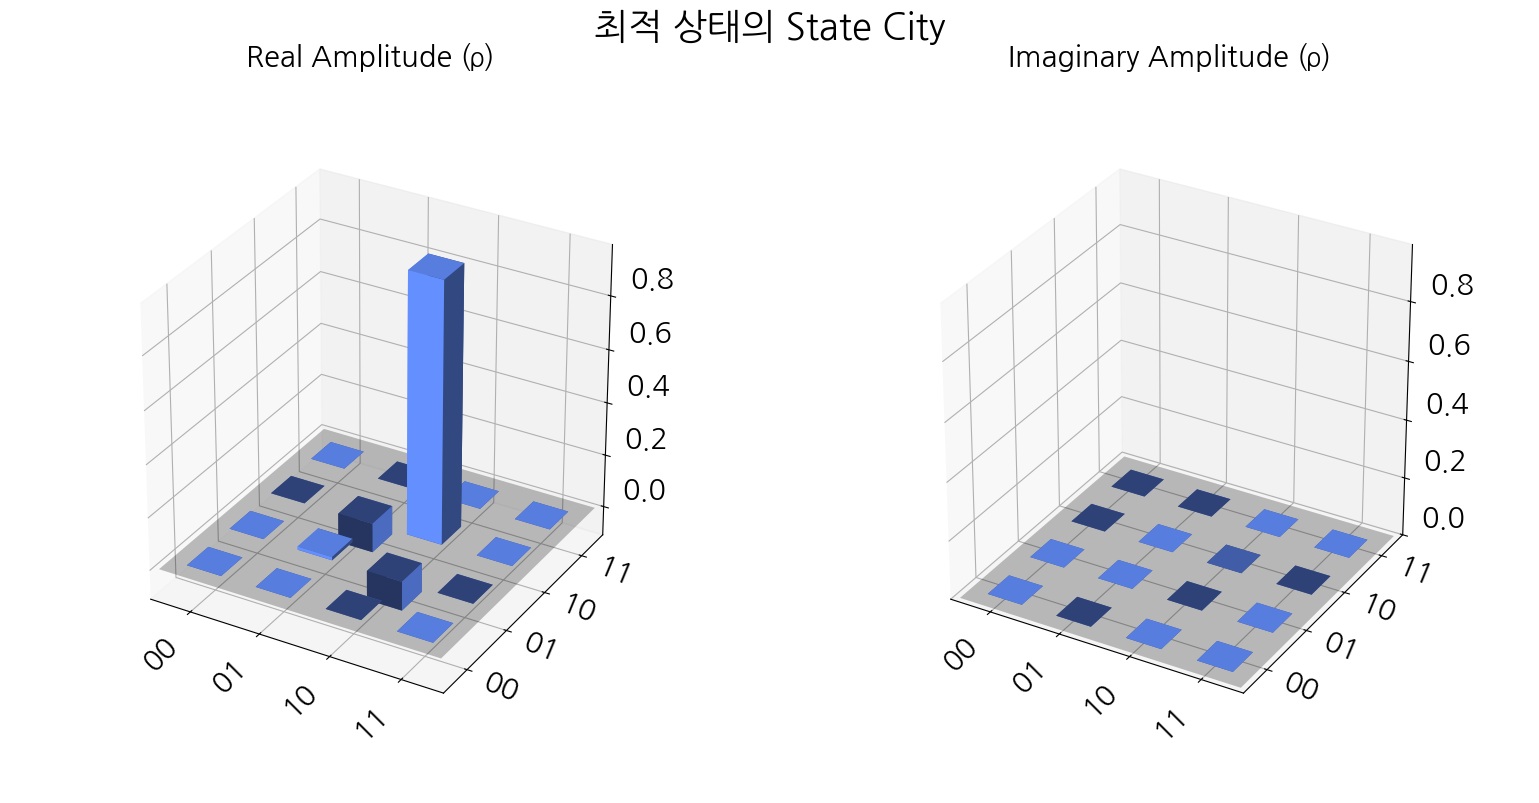

In [33]:
# state_city로 상태 시각화
plot_state_city(state, title="최적 상태의 State City")
plt.show()  # 호환성 수정

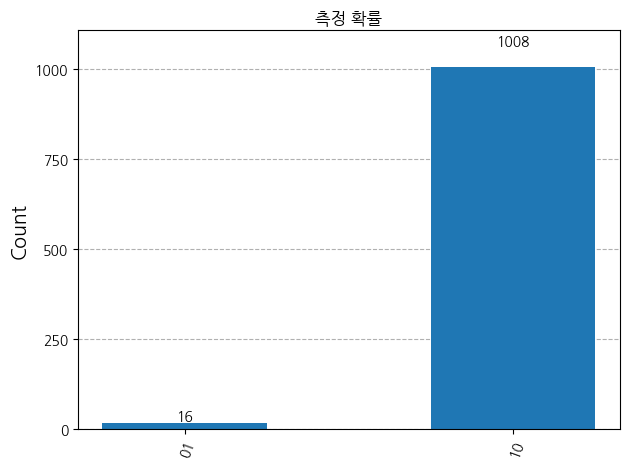

In [34]:
# 측정 확률을 히스토그램으로 계산·시각화
transpiled_circuit.measure_all()
counts = simulator.run(transpiled_circuit).result().get_counts()
plot_histogram(counts, title="측정 확률")
plt.show()  # 호환성 수정

In [35]:
# 상태벡터를 밀도행렬로 변환
density_matrix = state.to_operator().data

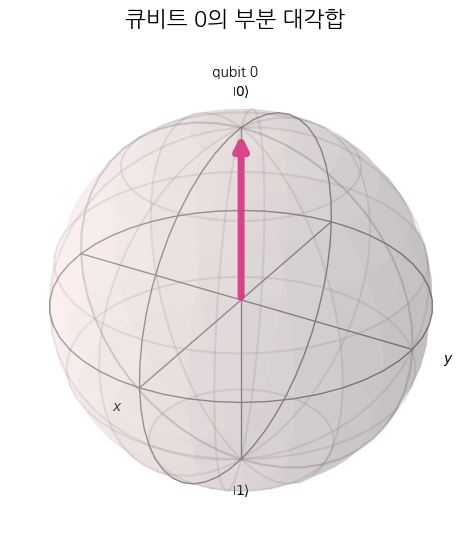

In [36]:
# 부분 대각합
partial_trace_rho = partial_trace(density_matrix, [1])
plot_bloch_multivector(partial_trace_rho, title="큐비트 0의 부분 대각합")
plt.show()  # 호환성 수정